Ethan Ho
017157582
CMPE 188

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import KFold, cross_val_score, train_test_split
import seaborn as sns
from sklearn.neural_network import MLPRegressor

In [29]:
data = pd.read_csv("E:/vs/school/CMPE_188/data/boston.csv")
data.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'crim'}>, <Axes: title={'center': 'zn'}>,
        <Axes: title={'center': 'indus'}>],
       [<Axes: title={'center': 'chas'}>,
        <Axes: title={'center': 'nox'}>, <Axes: title={'center': 'rm'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'dis'}>, <Axes: title={'center': 'rad'}>,
        <Axes: title={'center': 'tax'}>,
        <Axes: title={'center': 'ptratio'}>],
       [<Axes: title={'center': 'black'}>,
        <Axes: title={'center': 'lstat'}>,
        <Axes: title={'center': 'medv'}>, <Axes: >]], dtype=object)

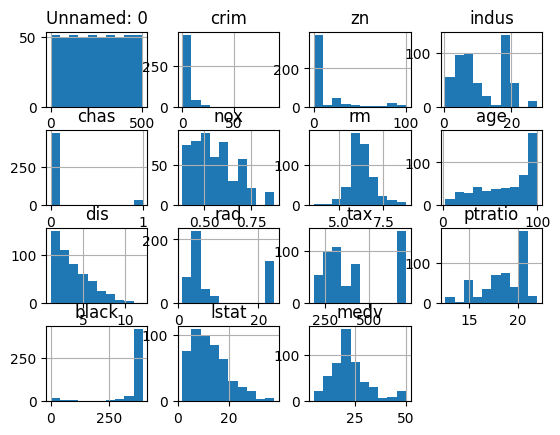

In [30]:
data.hist()

I am going to remove unamed as it seems to be an index column. Also many of the distributions are sked so i'll likely transform the data with either square root or log transform

In [31]:
# Splitting Data
data = data.drop(['Unnamed: 0'], axis=1)
x = data.drop(['medv'], axis=1)
y = pd.DataFrame(data['medv'])

x.head()
y.head()

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


array([[<Axes: title={'center': 'crim'}>, <Axes: title={'center': 'zn'}>,
        <Axes: title={'center': 'indus'}>,
        <Axes: title={'center': 'chas'}>],
       [<Axes: title={'center': 'nox'}>, <Axes: title={'center': 'rm'}>,
        <Axes: title={'center': 'age'}>, <Axes: title={'center': 'dis'}>],
       [<Axes: title={'center': 'rad'}>, <Axes: title={'center': 'tax'}>,
        <Axes: title={'center': 'ptratio'}>,
        <Axes: title={'center': 'black'}>],
       [<Axes: title={'center': 'lstat'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

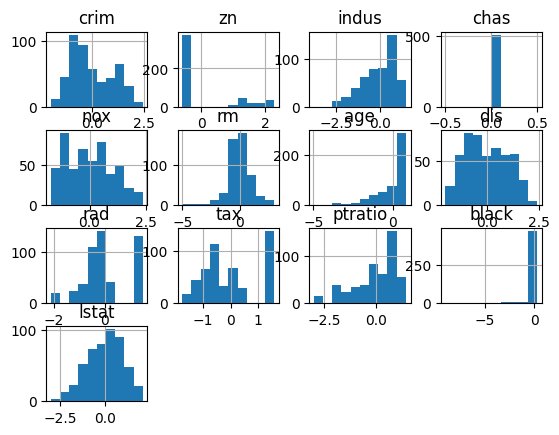

In [32]:
# Transforming Data
x = np.sqrt(x)
x = np.log(x.mask(x <=0)).fillna(0)

scaler = StandardScaler()
scaler.fit(x)
x = pd.DataFrame(scaler.transform(x), columns=x.columns)

x.hist()

We can see that it definently helped some distributions center more although there are some columns that are largly one value. 

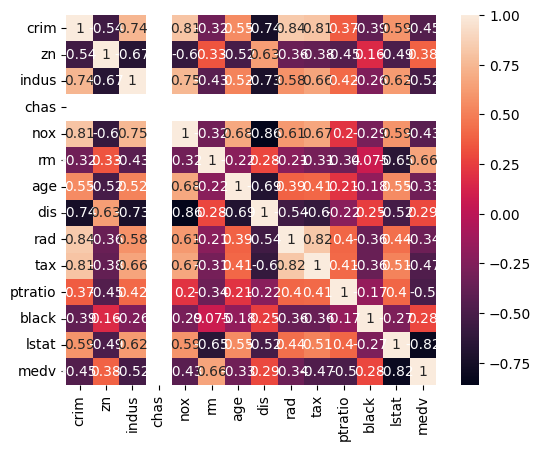

In [35]:
df = pd.concat([x,y], axis=1)

plt.figure()
heapmap = df.corr(method='pearson')
sns.heatmap(heapmap, square=True, annot=True)
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.rcParams['figure.figsize'] = [16, 20]
plt.show()

c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


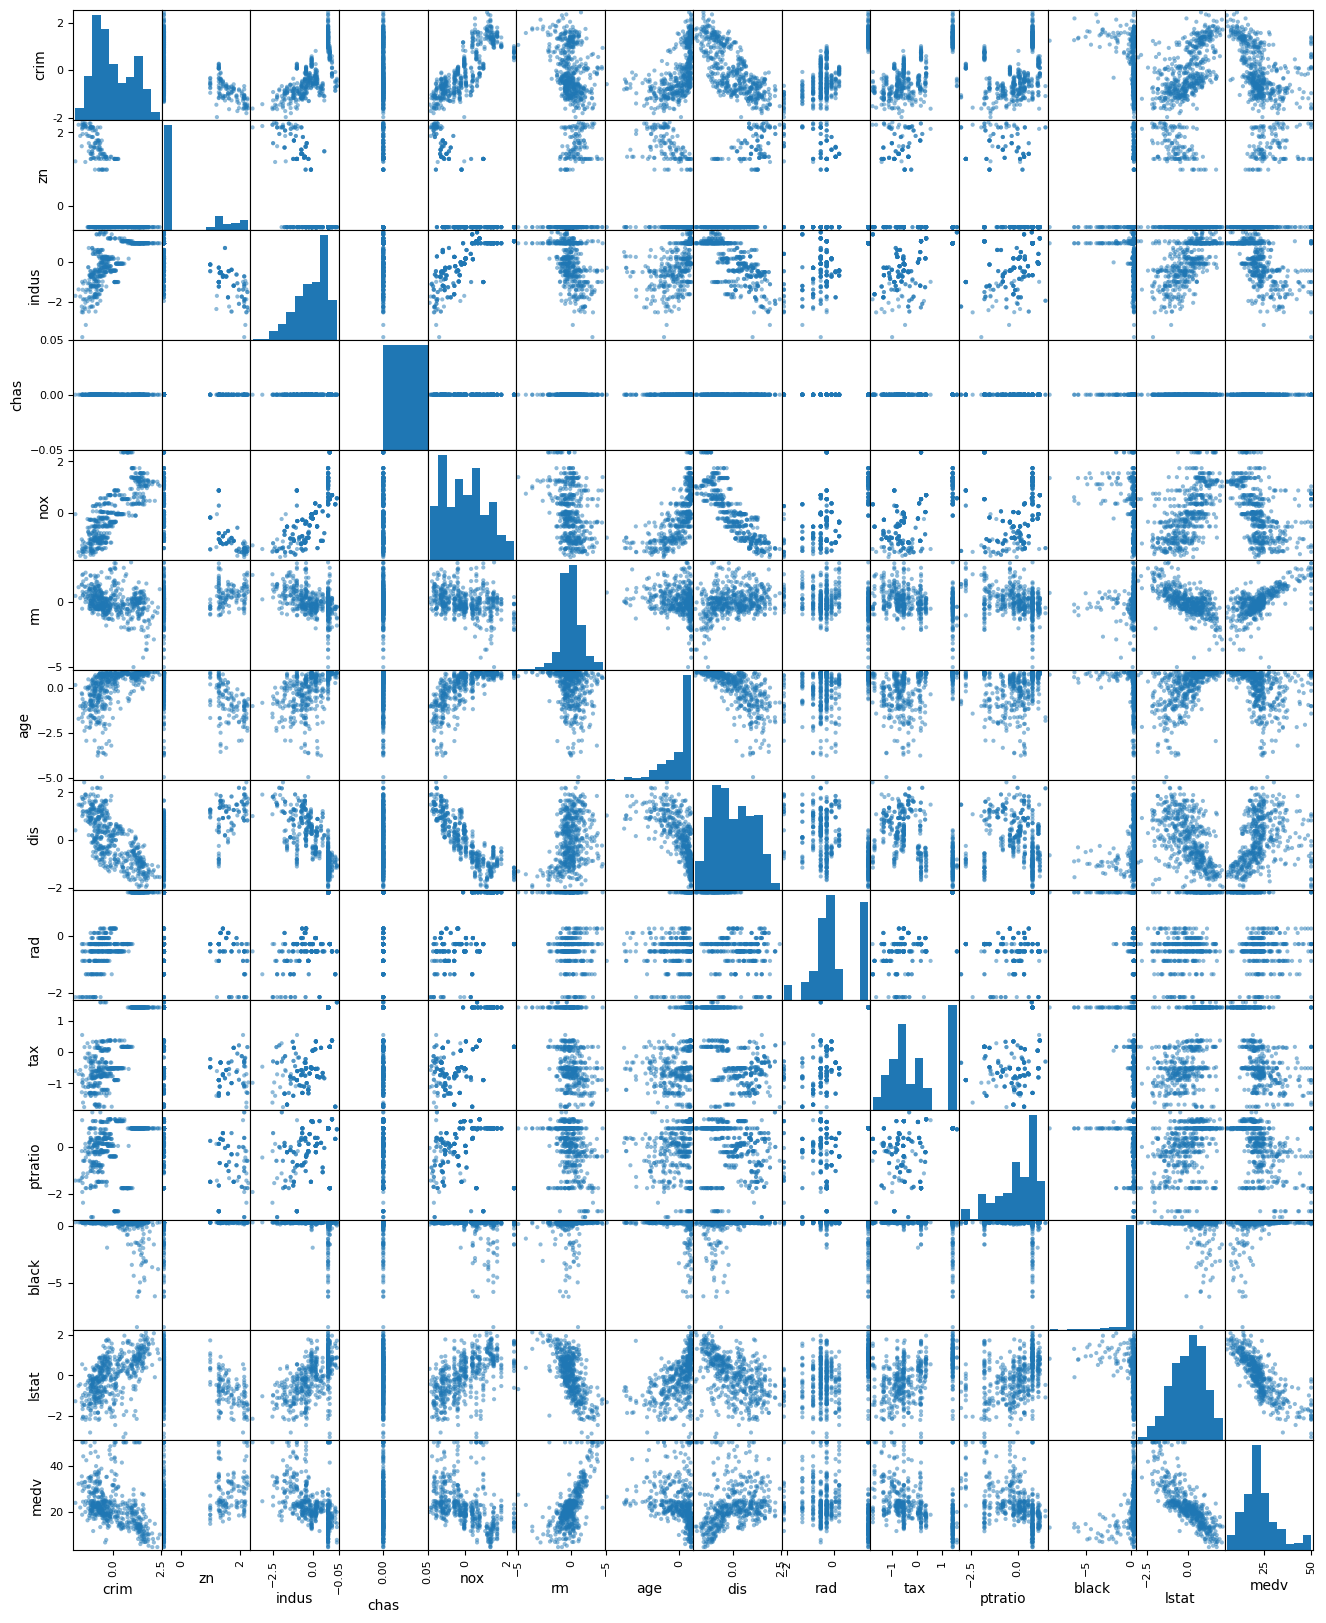

In [37]:
scatter_matrix(df)
plt.show()

After looking at the heatmap and scatter matrix, I choose a few variables that were higher in correlation to our output with a score of 0.4 and higher

In [39]:
x = df[['rm', 'lstat', 'ptratio', 'indus', 'tax', 'crim']]

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

Now applying cross validation to compare models with MLP. Im going to use socastic gradient descendent with an activation function of RELU because that is the standard. Here I put the learning rate a 0.0005 as that is a hyper parameter I tweaked by +/- 0.0001 all with relativly similar scores.

In [46]:
mlp = MLPRegressor(random_state=42, max_iter=1600, solver='sgd', learning_rate_init=0.0006, activation='relu', hidden_layer_sizes=(157, 5), momentum=0.86)
scoring = 'r2'

kfold = KFold(n_splits=10)
cv_results = cross_val_score(mlp, x_train, np.ravel(y_train), cv=kfold, scoring=scoring)

print("\tMean: ", cv_results.mean(), "\tSTD: ", cv_results.std())
print("results: ", cv_results)

mlp.fit(x_train, np.ravel(y_train))
print("score: ", mlp.score(x_test, y_test))

c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1600) reached and the optimization hasn't converged yet.
  warnings.warn(


	Mean:  0.8558637812919632 	STD:  0.07148275676843012
results:  [0.83268459 0.88813843 0.92486877 0.73182923 0.86972581 0.91119857
 0.9205402  0.88635999 0.88028832 0.71300389]
score:  0.7703042178374753


After running the cross validation we can see that the score in testing was much lower than the score in training meaning that our MLP was a tad bit overfitted to our data. Perhaps next time we could decrease the number of hidden layers and try a method of dropping dead weight nodes in the graph.